## Freeman Chain Code F4 Method for bi level images on Python

## Import Libraries

In [ ]:
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

## Upload Image

In [2]:
ruta = input("Introduce la ruta del GIF: ")

imagen = Image.open(ruta)
imagen.seek(0)

# Convertimos el GIF a escala de grises
imagen = imagen.convert("L")

# Lo convertimos en matriz NumPy
matriz = np.array(imagen)

print("Tamaño:", matriz.shape)
print("Valores encontrados:", np.unique(matriz))

Tamaño: (562, 632)
Valores encontrados: [  0 255]


## Show image

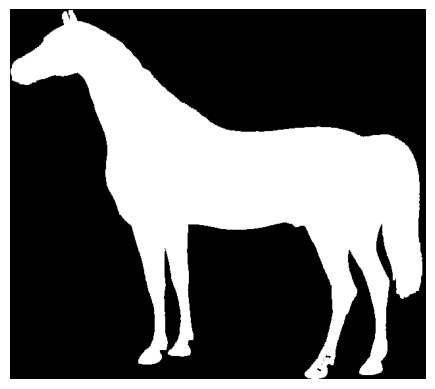

In [3]:
import matplotlib.pyplot as plt

plt.imshow(matriz, cmap="gray")
plt.axis("off")
plt.show()

## Get pixels

In [4]:
def encontrar_inicio(imagen):
    alto, ancho = imagen.shape

    for y in range(alto):
        for x in range(ancho):
            if imagen[y, x] == 255:
                return y, x

inicio = encontrar_inicio(matriz)

print("Inicio:", inicio)

direcciones = {
    0: (-1, 0),   # arriba
    1: (0, 1),    # derecha
    2: (1, 0),    # abajo
    3: (0, -1)    # izquierda
}



def siguiente_pixel(imagen, actual, direccion_anterior):

    y, x = actual
    alto, ancho = imagen.shape

    # Orden de búsqueda en sentido horario.
    #
    # Primero intentamos girar a la derecha,
    # después continuar recto,
    # después izquierda,
    # finalmente retroceder.
    orden = [
        (direccion_anterior + 1) % 4,
        direccion_anterior,
        (direccion_anterior + 3) % 4,
        (direccion_anterior + 2) % 4
    ]

    for direccion in orden:

        dy, dx = direcciones[direccion]

        nuevo_y = y + dy
        nuevo_x = x + dx

        # Comprobar límites
        if 0 <= nuevo_y < alto and 0 <= nuevo_x < ancho:

            # ¿Es parte del objeto?
            if imagen[nuevo_y, nuevo_x] == 255:

                return (nuevo_y, nuevo_x), direccion

    return None, None

Inicio: (1, 89)


## Test neighbors

In [5]:
direccion_inicial = 1

def obtener_chain_code(imagen, inicio):

    actual = inicio

    # Dirección inicial: derecha
    direccion_anterior = 1

    cadena = []
    recorrido = [inicio]

    alto, ancho = imagen.shape

    # Límite de seguridad para evitar ciclos infinitos
    max_iteraciones = alto * ancho

    for _ in range(max_iteraciones):

        siguiente, direccion = siguiente_pixel(
            imagen,
            actual,
            direccion_anterior
        )

        # No encontramos otro píxel
        if siguiente is None:
            print("No se encontró un siguiente píxel.")
            break

        cadena.append(direccion)
        recorrido.append(siguiente)

        actual = siguiente
        direccion_anterior = direccion

        # Regresamos al inicio
        if actual == inicio and len(cadena) > 1:
            break

    return cadena, recorrido
cadena, recorrido = obtener_chain_code(matriz, inicio)

## Get String

In [6]:
cadena_string = ''.join(map(str, cadena))

print("Chain Code F4:")
print(cadena_string)

print("\nLongitud:", len(cadena_string))

Chain Code F4:
2222222112222222330003003000300030333232232322222221122222212222332332332332332332332323323233232323233232323322332222232232323223323223332233322332323323233233233233232323332233233332323323232332232322322222322322222212221222222211211211121112121211111112111111011011010111111000111101110111111011011101101110111101111211111111211101111110111101110111011110112121122112121212211221221221221221222122122222122221222122212212212221221222221222212221221222122122122221212221221221222122212212212222122221222221222222122222222222222222232222222322222222222223222222222221222222212222221221222122122121221221212212221212212221222122122221222122122221121212212121212211212121212121121212221222212221222212221222212221222212221222122221221221222212221222212222122222122221222222212221222222212212222212222212222122212122221222122212222122122222122222122322212222222222222222222222222222232222232222223223223222322233223233232332323223232323232232322232322222121111121111111111111101111101110

## Show route

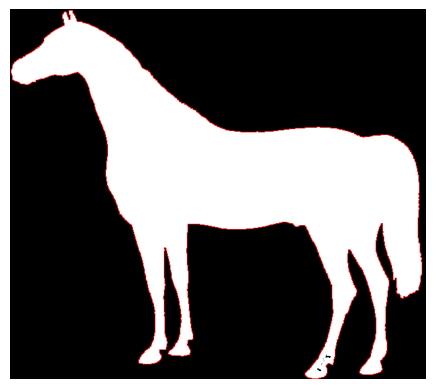

In [7]:
imagen_recorrido = cv2.cvtColor(matriz, cv2.COLOR_GRAY2BGR)

for i in range(len(recorrido) - 1):

    y1, x1 = recorrido[i]
    y2, x2 = recorrido[i + 1]

    cv2.line(
        imagen_recorrido,
        (x1, y1),
        (x2, y2),
        (0, 0, 255),
        1
    )

#plt.figure(figsize=(12, 10))
plt.imshow(cv2.cvtColor(imagen_recorrido, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()